## 1 · Imports

In [78]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp


In [79]:
import muon as mu
from muon import MuData

## 2 · Data Loading

Load mudata

In [80]:
mdata = mu.read_h5mu("mdata_12022026.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


[<Axes: title={'center': 'rna_leiden'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'rna_leiden_05'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'gex03'}, xlabel='UMAP1', ylabel='UMAP2'>]

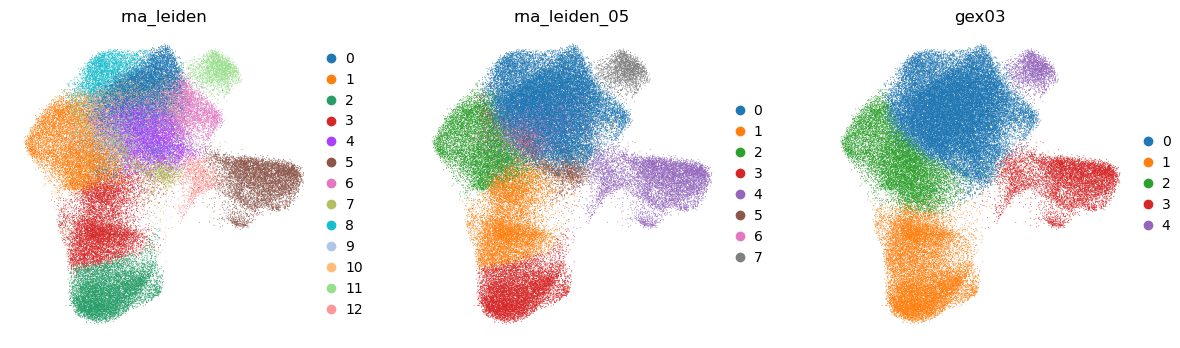

In [15]:
sc.pl.umap(
    mdata["gex"],
    color=["rna_leiden", "rna_leiden_05", "gex03"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)


## 3. Data layers: X contains log norm counts and X contains raw counts 

In [20]:
X = mdata["gex"].X

if sp.issparse(X):
    data = X.data
else:
    data = X.flatten()

print("Min:", data.min())
print("Max:", data.max())
print("Any decimals:", np.any(data % 1 != 0))

Min: 0.10239302
Max: 8.469446
Any decimals: True


In [21]:
if "counts" in mdata["gex"].layers:
    C = mdata["gex"].layers["counts"]

    if sp.issparse(C):
        C = C.data

    print("Counts contain decimals:", np.any(C % 1 != 0))
    print("Counts max:", C.max())

Counts contain decimals: False
Counts max: 6407.0


## 4. Quality control (QC) outlier detection 

Median Absolute Deviation (MAD) method

In [25]:
def is_outlier(
    adata: AnnData, metric_col: str, *, groupby: Optional[str] = None, n_mads: float = 5
) -> pd.Series:
    """Detect outliers by median absolute deviation (MAD).

    Adapted from https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html#motivation

    Parameters
    ----------
    adata
        AnnData object
    metric_col
        column in adata.obs to consider
    groupby
        grouping variable. If specified, outliers will be determined for each value of this grouping variable separately.
        E.g. `dataset`.
    n_mads
        label points that are outside of median +/- nmads * MAD.
    """

    def _is_outlier(df):
        """Check if metric value deviates from the median by more than n_mads MADs."""
        metric_values = df[metric_col]
        return np.abs(
            metric_values - np.median(metric_values)
        ) > n_mads * median_abs_deviation(metric_values)

    if groupby is None:
        return _is_outlier(adata.obs)
    else:
        return adata.obs.groupby(groupby, observed=False).apply(_is_outlier).droplevel(groupby).reindex(adata.obs_names)  # type: ignore

In [29]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

### Before

[<Axes: title={'center': 'pct_counts_mito'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'total_counts'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'n_genes_by_counts'}, xlabel='UMAP1', ylabel='UMAP2'>]

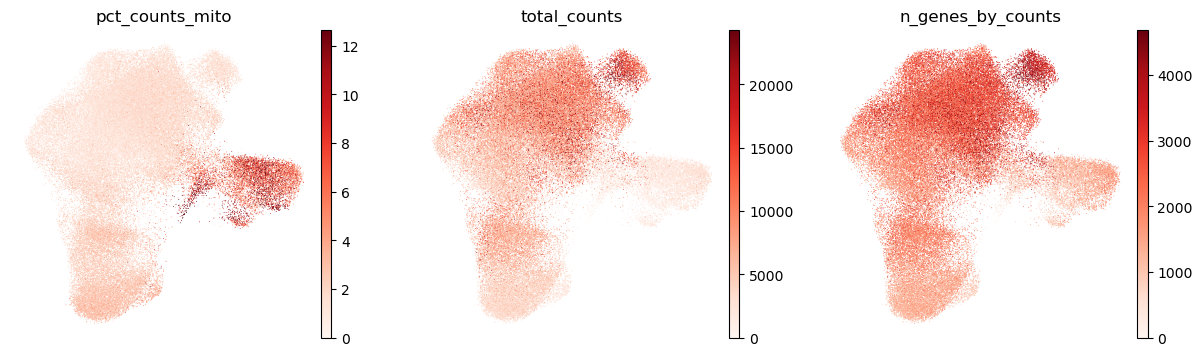

In [22]:
sc.pl.umap(
    mdata["gex"],
    color=["pct_counts_mito", "total_counts", "n_genes_by_counts"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)


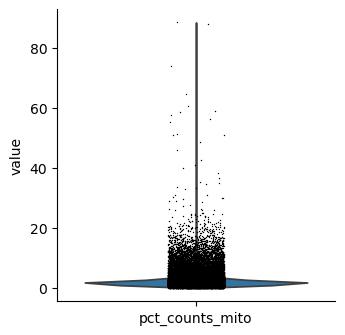

In [23]:
sc.pl.violin(mdata["gex"], "pct_counts_mito")

In [26]:
# Outlier
n_mads = 5
mdata["gex"].obs["is_outlier_counts"] = is_outlier(
    mdata["gex"], "log1p_total_counts", n_mads=n_mads, groupby="sample_id"
)
mdata["gex"].obs["is_outlier_genes"] = is_outlier(
    mdata["gex"], "log1p_n_genes_by_counts", n_mads=n_mads, groupby="sample_id"
)
mdata["gex"].obs["is_outlier_top_20"] = is_outlier(
    mdata["gex"], "pct_counts_in_top_20_genes", n_mads=n_mads, groupby="sample_id"
)
mdata["gex"].obs["is_outlier_mito"] = is_outlier(
    mdata["gex"], "pct_counts_mito", n_mads=n_mads, groupby="sample_id"
)

mdata["gex"].obs["is_outlier"] = (
    np.sum(
        mdata["gex"].obs.loc[
            :,
            [
                "is_outlier_counts",
                "is_outlier_genes",
                "is_outlier_top_20",
                "is_outlier_mito",
            ],
        ],
        axis=1,
    )
    >= 2
)

/tmp/ipykernel_3147298/2356920737.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return adata.obs.groupby(groupby, observed=False).apply(_is_outlier).droplevel(groupby).reindex(adata.obs_names)  # type: ignore
/tmp/ipykernel_3147298/2356920737.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return adata.obs.groupby(groupby, observed=False).apply(_is_outlier).droplevel(groupby).reindex(adata.obs_names)  # t

In [28]:
mdata["gex"].obs.is_outlier.value_counts()

is_outlier
False    71786
True       806
Name: count, dtype: int64

In [30]:
mdata["gex"].obs["mt_outlier"] = is_outlier( mdata["gex"], "pct_counts_mito", 3) | (
     mdata["gex"].obs["pct_counts_mito"] > 12
)
mdata["gex"].obs.mt_outlier.value_counts()

mt_outlier
False    64091
True      8501
Name: count, dtype: int64

In [31]:
print(f"Total number of cells: {mdata.n_obs}")
mdata = mdata[(~mdata["gex"].obs.is_outlier) & (~mdata["gex"].obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {mdata.n_obs}")

Total number of cells: 72592
Number of cells after filtering of low quality cells: 63948


/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [32]:
mdata.update()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### After

[<Axes: title={'center': 'pct_counts_mito'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'total_counts'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'n_genes_by_counts'}, xlabel='UMAP1', ylabel='UMAP2'>]

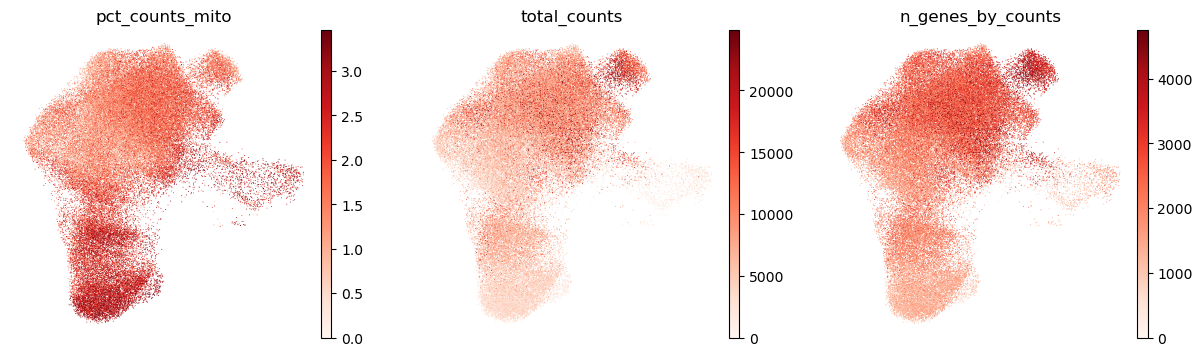

In [33]:
sc.pl.umap(
    mdata["gex"],
    color=["pct_counts_mito", "total_counts", "n_genes_by_counts"],
    cmap="Reds",
    vmin=0,
    vmax="p99",
    sort_order=False,
    show=False, frameon=False
)


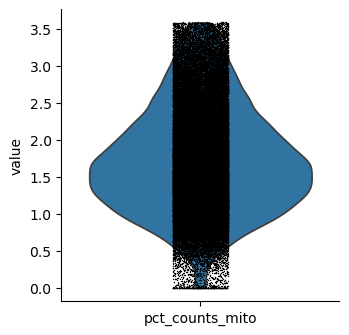

In [34]:
sc.pl.violin(mdata["gex"], "pct_counts_mito")

In [35]:
sc.pp.pca(mdata["gex"], svd_solver="arpack")

In [36]:
sc.pp.neighbors(mdata["gex"], n_pcs=20)

2026-05-28 13:39:48.747786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 13:39:48.808469: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 5. RNA together with protein expression

In [41]:
import numpy as np
import pandas as pd

gex = mdata["gex"]
adt = mdata["adt"]

# ADT as dataframe (cells x proteins)
adt_df = mdata["adt"].to_df()

# Align to gex cells (adds NaN rows for gex cells that don't have ADT)
adt_df_aligned = adt_df.reindex(mdata["gex"].obs_names)

# store in obsm (must be array-like with matching row order)
mdata["gex"].obsm["protein"] = adt_df_aligned.to_numpy()
mdata["gex"].uns["protein_columns"] = adt_df_aligned.columns.to_list()  # keep feature names somewhere

# If you also want ADT UMAP aligned (NaN for missing)
if "X_umap" in  mdata["adt"].obsm:
    prot_umap = pd.DataFrame(mdata["adt"].obsm["X_umap"], index= mdata["adt"].obs_names).reindex( mdata["gex"].obs_names)
    gex.obsm["protein_umap"] = prot_umap.to_numpy()

# If you want protein leiden aligned (NaN for missing)
if "protein_leiden" in adt.obs:
    gex.obs["protein_leiden"] = adt.obs["protein_leiden"].reindex(gex.obs_names)

print("GEX cells:", mdata["gex"].n_obs)
print("ADT cells:", mdata["adt"].n_obs)
print("Protein matrix in gex.obsm['protein']:", mdata["gex"].obsm["protein"].shape)

GEX cells: 63948
ADT cells: 52200
Protein matrix in gex.obsm['protein']: (63948, 9)


## 6. CLR normalization (Centered Log Ratio normalization) to ADT/protein counts. 

In [45]:
mu.prot.pp.clr(mdata["adt"], inplace = True)

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/muon/_prot/preproc.py:219: UserWarning: adata.X is sparse but not in CSC format. Converting to CSC.
  warn("adata.X is sparse but not in CSC format. Converting to CSC.")


## 7. Ploting RNA & protein on GEX:Umap

In [55]:
import muon as mu
import matplotlib.pyplot as plt

axes = mu.pl.embedding(
    mdata,
    basis="gex:X_umap",
    color=[
        "CD44_TotalSeqC","Cd44",
        "CD103_TotalSeqC","Itgae",
        "CD69_TotalSeqC","Cd69",
        "PD1_TotalSeqC","Pdcd1"
    ],
    frameon=True,
    vmax="p99",
    cmap="Reds",
    ncols=2,title=["CD44","Cd44",
        "CD103","Itgae",
        "CD69","Cd69",
        "PD1","Pdcd1"], 
    show=False
)

for ax in axes:
    ax.set_xlabel("UMAP1", fontsize=8)
    ax.set_ylabel("UMAP2", fontsize=8)
    ax.tick_params(axis='both', labelsize=6)



#plt.savefig("multi_umap_markers.png", dpi=300, bbox_inches="tight")
plt.close()

### Plotting cycling marker

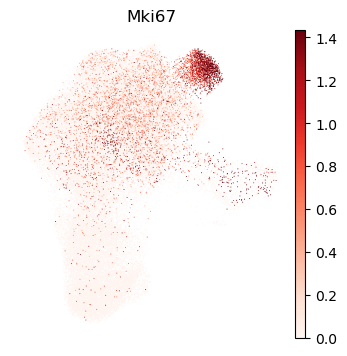

In [57]:
mu.pl.embedding(mdata, basis="gex:X_umap", color=["Mki67"], frameon=False, vmax="p99", cmap="Reds")